In [ ]:
pip install prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.0/179.0 kB 15.2 MB/s eta 0:00:00


# FAMD

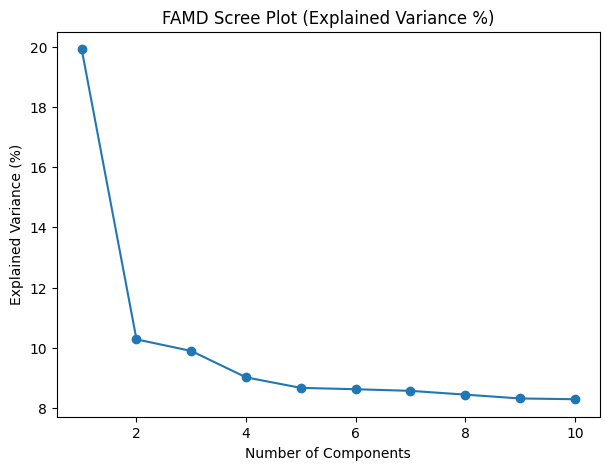

Explained Variance (%):
[19.92 10.28  9.89  9.02  8.67  8.62  8.57  8.44  8.31  8.29]

Cumulative Explained Variance (%):
[ 19.92  30.19  40.08  49.1   57.77  66.39  74.95  83.4   91.71 100.  ]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import prince

# Load dataset
df = pd.read_csv("Train Dataset without Target.csv")

# Drop 'price' and 'Log Price' columns as requested, ignoring errors if they don't exist
df = df.drop(columns=['Price', 'LogPrice'], errors='ignore')


# Convert categorical columns to string
cat_cols = df.select_dtypes(include=['object','category']).columns
for col in cat_cols:
    df[col] = df[col].astype(str)

# Apply FAMD
famd = prince.FAMD(
    n_components=10,
    random_state=42
)

famd.fit(df)

# Explained variance in percentage
# Calculate explained variance ratio from eigenvalues_ and convert to percentage
if hasattr(famd, 'eigenvalues_'):
    eigenvalues = famd.eigenvalues_
    explained_variance_pct = (eigenvalues / eigenvalues.sum()) * 100
else:
    raise AttributeError("Eigenvalues_ not found after FAMD fit, cannot calculate explained variance.")

# Cumulative explained variance
cumulative_variance_pct = np.cumsum(explained_variance_pct)

# Scree Plot
plt.figure(figsize=(7,5))
plt.plot(range(1, len(explained_variance_pct)+1),
         explained_variance_pct,
         marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Explained Variance (%)")
plt.title("FAMD Scree Plot (Explained Variance %)")
plt.show()

# Print values
print("Explained Variance (%):")
print(np.round(explained_variance_pct, 2))

print("\nCumulative Explained Variance (%):")
print(np.round(cumulative_variance_pct, 2))

In [ ]:
famd = prince.FAMD(n_components=10, random_state=42)
famd = famd.fit(df)

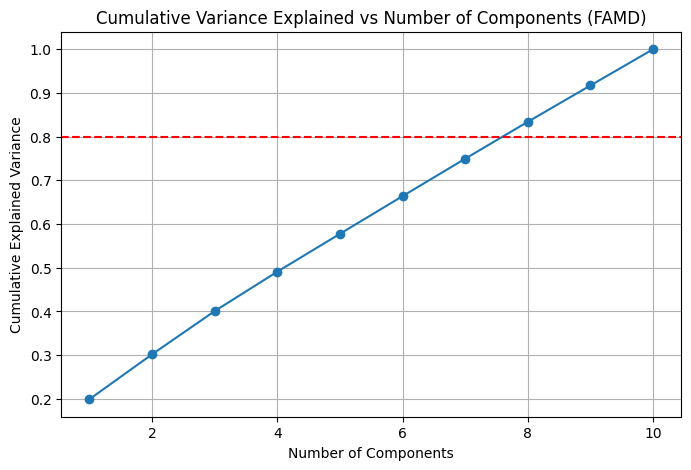

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Explained variance ratio
# Calculate explained variance ratio from eigenvalues_ as explained_inertia_ is not available
if hasattr(famd, 'eigenvalues_'):
    explained_var = famd.eigenvalues_ / famd.eigenvalues_.sum()
else:
    raise AttributeError("Eigenvalues_ not found after FAMD fit, cannot calculate explained variance.")

# Cumulative sum
cumulative_var = np.cumsum(explained_var)

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o')
plt.axhline(y=0.80, linestyle='--',color='red')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained vs Number of Components (FAMD)")
plt.grid(True)
plt.show()

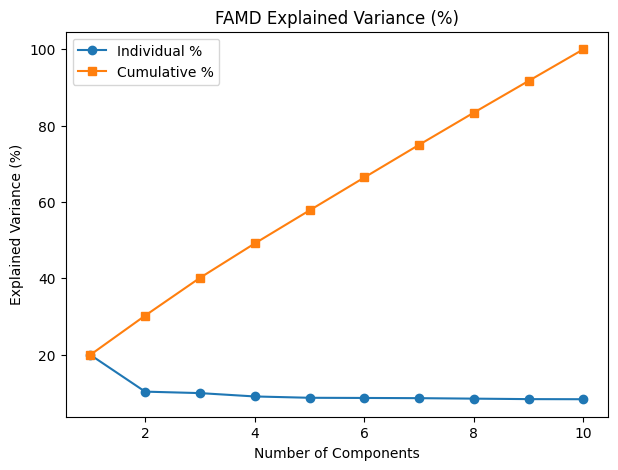

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(range(1, len(explained_variance_pct)+1),
         explained_variance_pct,
         marker='o',
         label="Individual %")

plt.plot(range(1, len(cumulative_variance_pct)+1),
         cumulative_variance_pct,
         marker='s',
         label="Cumulative %")

plt.xlabel("Number of Components")
plt.ylabel("Explained Variance (%)")
plt.legend()
plt.title("FAMD Explained Variance (%)")
plt.show()

In [ ]:
!pip install prince
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import prince

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

In [ ]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [ ]:
for col in cat_cols:
    df[col] = df[col].astype(str)

In [ ]:
famd = prince.FAMD(
    n_components=10,   # You can adjust
    random_state=42
)

famd = famd.fit(df)

# Transform dataset into FAMD components
df_famd = famd.transform(df)

df_famd.head()

component,0,1,2,3,4,5,6,7,8,9
0,-0.691483,-0.825916,0.746700,-0.085445,-2.598758,-2.227743,-3.592000,0.537690,-0.477983,0.286765
1,-2.240004,1.277838,-0.516994,0.204541,0.448862,-0.663544,2.054604,-0.333317,-1.864777,1.171535
2,1.461017,0.677565,-0.703225,-1.138180,-2.543098,-2.765536,-2.322650,0.290676,-0.204985,-1.339194
3,-3.100406,1.633700,-0.042579,-0.212779,2.555971,-2.158915,0.691622,-3.200806,-0.095469,0.013925
4,0.994968,-0.924232,-1.000153,1.569892,-1.950070,-1.444171,0.808220,1.027703,2.073426,0.612196


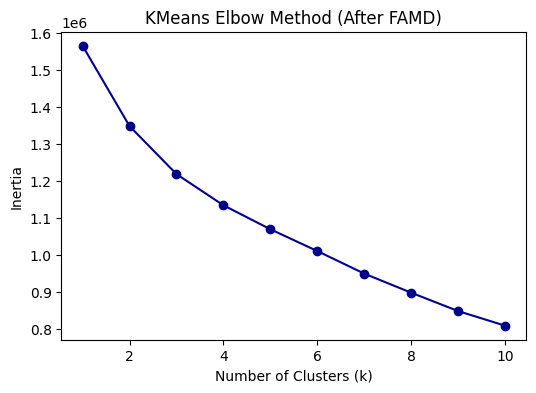

In [ ]:
inertia = []


for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_famd)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), inertia, marker='o',color='darkblue')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("KMeans Elbow Method (After FAMD)")
plt.show()

## UMAP

In [ ]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(df_famd)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


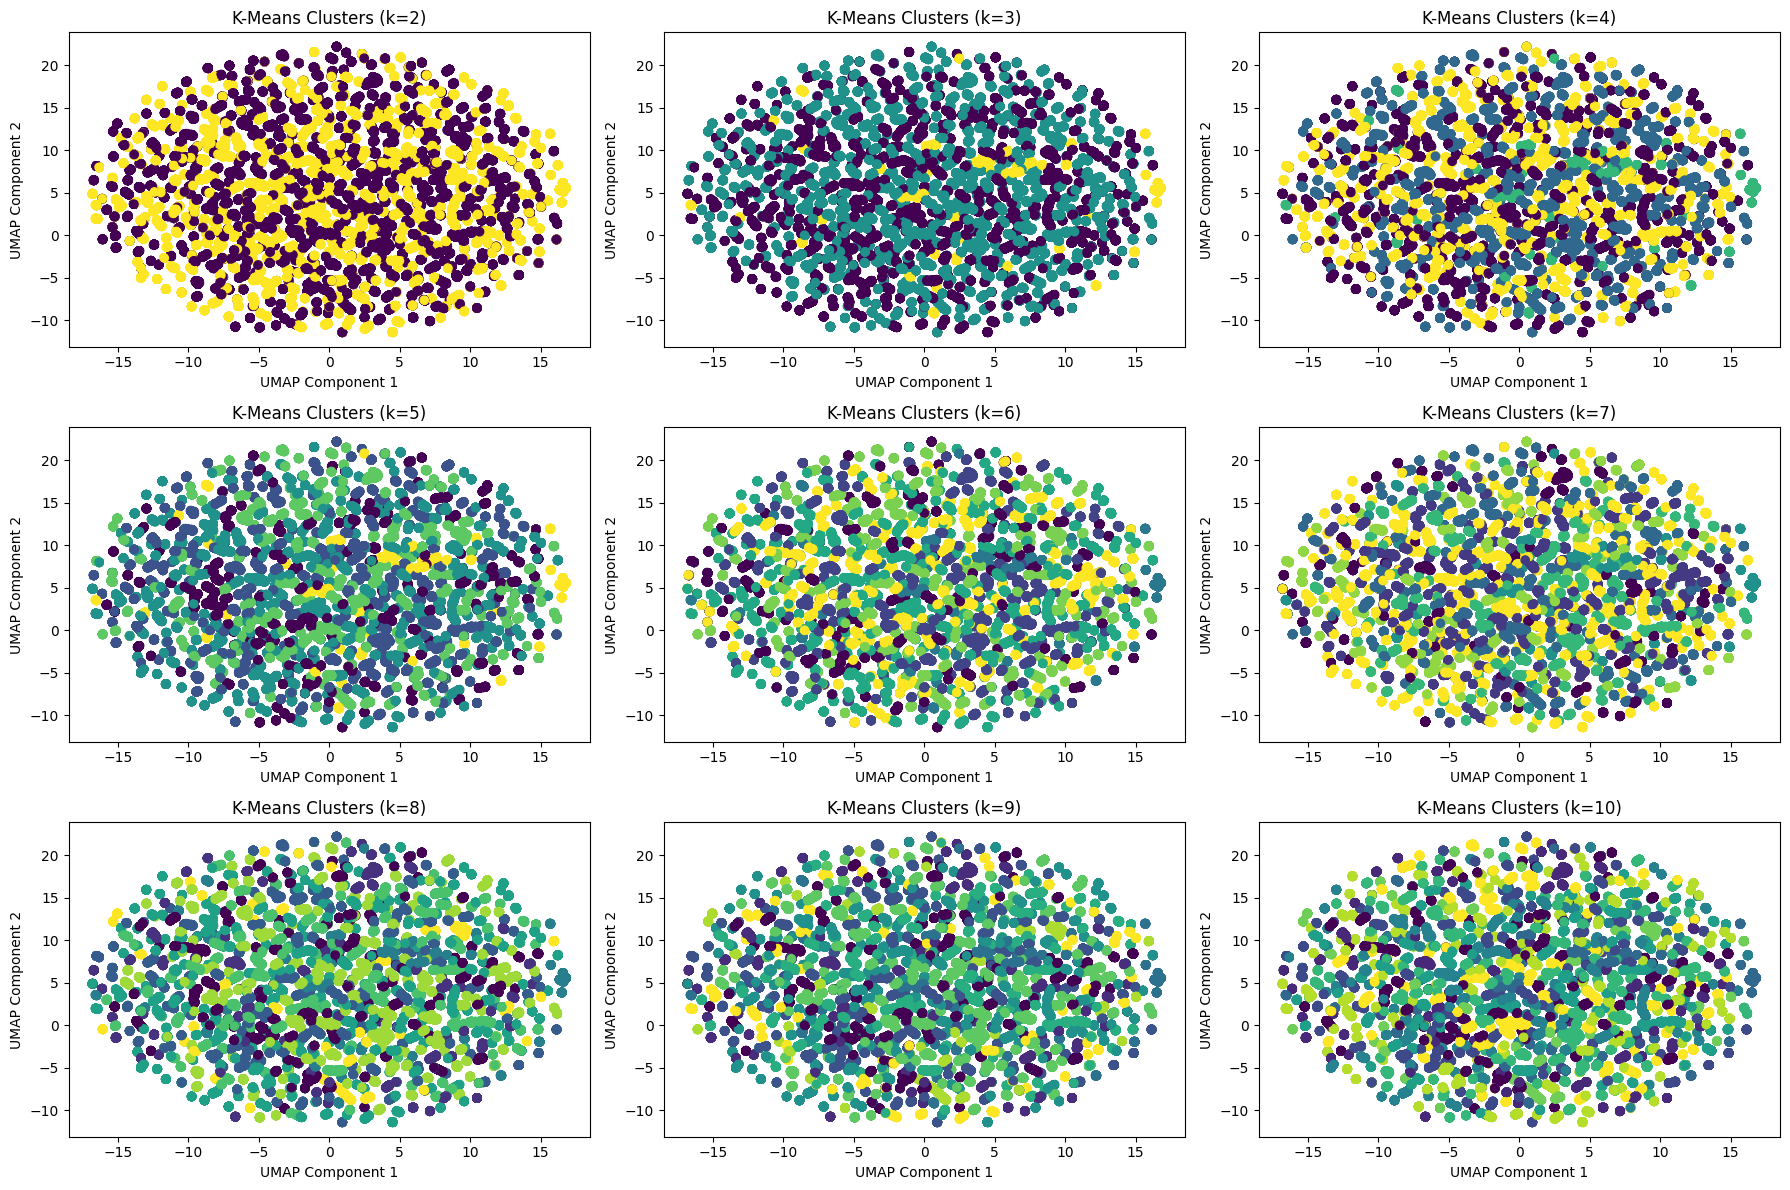

In [ ]:
K_range = range(2, 11)

plt.figure(figsize=(18, 12))

for i, k in enumerate(K_range):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_famd)

    plt.subplot(3, 3, i+1)
    plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels)
    plt.title(f'K-Means Clusters (k={k})')
    plt.xlabel("UMAP Component 1")
    plt.ylabel("UMAP Component 2")

plt.tight_layout()
plt.show()

## Silought Score

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

silhouette_scores = []
db_scores = []
k_values = range(2, 11)

print("Evaluating clusters...\n")

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_famd)

    sil_score = silhouette_score(df_famd, labels)
    db_index = davies_bouldin_score(df_famd, labels)

    silhouette_scores.append(sil_score)
    db_scores.append(db_index)

    print(f"k = {k} | Silhouette Score: {sil_score:.4f} | Davies-Bouldin Index: {db_index:.4f}")

Evaluating clusters...

k = 2 | Silhouette Score: 0.1384 | Davies-Bouldin Index: 2.3885
k = 3 | Silhouette Score: 0.1486 | Davies-Bouldin Index: 1.9279
k = 4 | Silhouette Score: 0.1218 | Davies-Bouldin Index: 2.1619
k = 5 | Silhouette Score: 0.1281 | Davies-Bouldin Index: 2.0282
k = 6 | Silhouette Score: 0.1324 | Davies-Bouldin Index: 1.9126
k = 7 | Silhouette Score: 0.1477 | Davies-Bouldin Index: 1.7901
k = 8 | Silhouette Score: 0.1540 | Davies-Bouldin Index: 1.6867
k = 9 | Silhouette Score: 0.1634 | Davies-Bouldin Index: 1.6409
k = 10 | Silhouette Score: 0.1642 | Davies-Bouldin Index: 1.6487


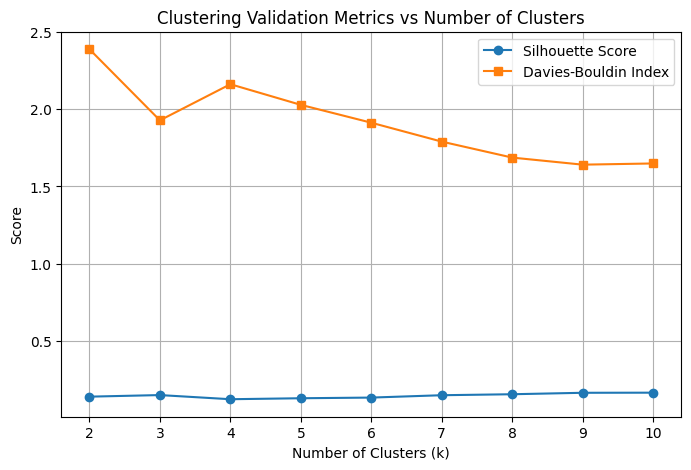

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(k_values, silhouette_scores, marker='o', label="Silhouette Score")
plt.plot(k_values, db_scores, marker='s', label="Davies-Bouldin Index")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.title("Clustering Validation Metrics vs Number of Clusters")
plt.legend()
plt.grid(True)

plt.show()

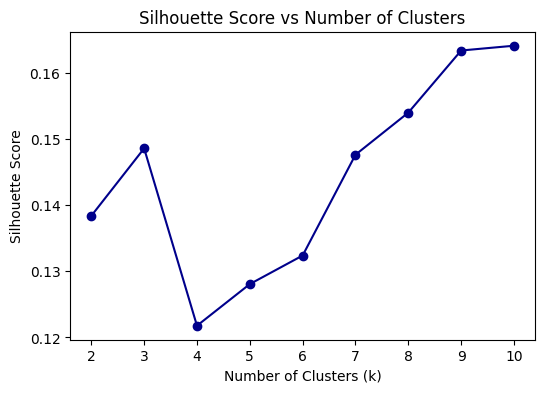

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []

k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_famd)
    score = silhouette_score(df_famd, labels)
    sil_scores.append(score)

# Plot
plt.figure(figsize=(6,4))
plt.plot(k_range, sil_scores, marker='o',color='darkblue')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

## Gower

In [ ]:
!pip install gower
!pip install kmodes

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from kmodes.kprototypes import KPrototypes
import gower

In [ ]:
df_sample = df   # adjust size if needed

In [ ]:
df_array = df_sample.to_numpy()
cat_indices = [df_sample.columns.get_loc(col) for col in cat_cols]

In [ ]:
cost = []


for k in range(2,11):   # You can reduce to 8 if dataset is large
    kproto = KPrototypes(
        n_clusters=k,
        init='Cao',      # Faster initialization
        n_init=2,        # Reduce for speed
        verbose=0,
        random_state=42
    )
clusters = kproto.fit_predict(df_array, categorical=cat_indices)

In [ ]:
gower_dist = gower.gower_matrix(df_sample)

In [ ]:
k_values = range(2, 11)
sil_scores = []

# Re-derive df_array and cat_indices from df_sample to ensure consistency
# df_sample has 20000 rows, so df_array and subsequent clusters should also reflect this.
df_array = df_sample.to_numpy()
cat_indices = [df_sample.columns.get_loc(col) for col in cat_cols]

for k in k_values:
    kproto = KPrototypes(
        n_clusters=k,
        init='Cao',
        n_init=3,
        random_state=42
    )

    clusters = kproto.fit_predict(df_array, categorical=cat_indices)

    score = silhouette_score(gower_dist, clusters, metric='precomputed')
    sil_scores.append(score)

    print(f"k={k} -> Silhouette Score: {score:.4f}")

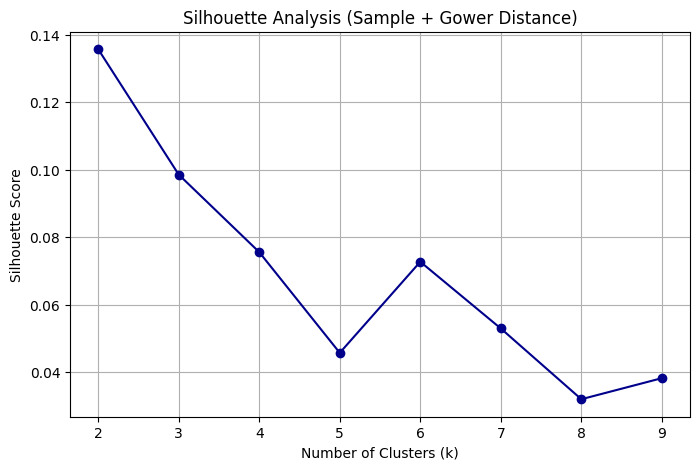

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(k_values, sil_scores, marker='o',color='darkblue')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis (Sample + Gower Distance)")
plt.grid(True)

plt.show()

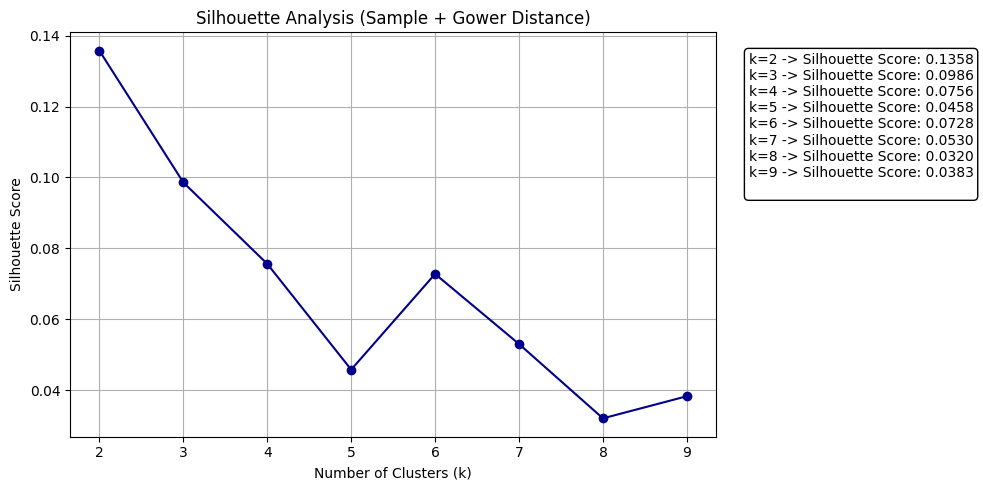

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(k_values, sil_scores, marker='o',color='darkblue')
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Analysis (Sample + Gower Distance)")
ax.grid(True)

# Print scores on right side
textstr = ""
for k, score in zip(k_values, sil_scores):
    textstr += f"k={k} -> Silhouette Score: {score:.4f}\n"

props = dict(boxstyle='round', facecolor='white')
ax.text(1.05, 0.95, textstr,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=props)

plt.tight_layout()
plt.show()